# Importar librerías

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
)

# Cargar recursos

In [2]:
# Ruta al directorio donde se encuentran los resultados de la experimentación
OUTPUT_FOLDER = Path("../../outputs/runs/nbaiot_lof_per_device_stage_2/devices")

In [3]:
# Rutas a los archivos de predicciones de cada modelo LOF por dispositivo
DEVICE_1_OUPUT_PATH = OUTPUT_FOLDER / "device_1" / "test_predictions.parquet"
DEVICE_2_OUPUT_PATH = OUTPUT_FOLDER / "device_2" / "test_predictions.parquet"
DEVICE_3_OUPUT_PATH = OUTPUT_FOLDER / "device_3" / "test_predictions.parquet"
DEVICE_4_OUPUT_PATH = OUTPUT_FOLDER / "device_4" / "test_predictions.parquet"
DEVICE_5_OUPUT_PATH = OUTPUT_FOLDER / "device_5" / "test_predictions.parquet"
DEVICE_6_OUPUT_PATH = OUTPUT_FOLDER / "device_6" / "test_predictions.parquet"
DEVICE_7_OUPUT_PATH = OUTPUT_FOLDER / "device_7" / "test_predictions.parquet"
DEVICE_8_OUPUT_PATH = OUTPUT_FOLDER / "device_8" / "test_predictions.parquet"
DEVICE_9_OUPUT_PATH = OUTPUT_FOLDER / "device_9" / "test_predictions.parquet"

In [4]:
# Cargar los resultados en un dataframe de pandas
results_df = pd.concat(
    [
        pd.read_parquet(DEVICE_1_OUPUT_PATH).assign(device=1),
        pd.read_parquet(DEVICE_2_OUPUT_PATH).assign(device=2),
        pd.read_parquet(DEVICE_3_OUPUT_PATH).assign(device=3),
        pd.read_parquet(DEVICE_4_OUPUT_PATH).assign(device=4),
        pd.read_parquet(DEVICE_5_OUPUT_PATH).assign(device=5),
        pd.read_parquet(DEVICE_6_OUPUT_PATH).assign(device=6),
        pd.read_parquet(DEVICE_7_OUPUT_PATH).assign(device=7),
        pd.read_parquet(DEVICE_8_OUPUT_PATH).assign(device=8),
        pd.read_parquet(DEVICE_9_OUPUT_PATH).assign(device=9)
    ],
    ignore_index=True
)

# Analizar resultados

## 1. Rendimiento global sobre el dataset de test completo

El primer paso del análisis consiste en evaluar el comportamiento global de los detectores LOF sobre el conjunto de test completo del dataset N-BaIoT. Para ello, se agregan las predicciones obtenidas por los nueve modelos entrenados, cada uno de ellos especializado en un dispositivo IoT distinto, permitiendo obtener una visión global del rendimiento de la estrategia basada en un detector LOF por dispositivo.

Es importante destacar que la distribución de clases presente en este conjunto de evaluación no representa la que habitualmente se encontraría en un entorno IoT real. Mientras que en un escenario de producción el tráfico benigno constituye la inmensa mayoría de las comunicaciones y los ataques representan únicamente una pequeña fracción del tráfico total, el conjunto de test empleado contiene un número muy superior de muestras maliciosas. Esta distribución responde a un objetivo experimental: evaluar la capacidad del detector frente al mayor número posible de muestras de ataque disponibles en el dataset.

Como consecuencia, algunas métricas de clasificación pueden verse condicionadas por este fuerte desbalanceo. En particular, métricas como la *Accuracy*, la *Precision* o la medida *F1* dependen, en mayor o menor medida, de la distribución de clases del conjunto de evaluación, por lo que no resultan las más adecuadas para realizar una valoración objetiva de la capacidad discriminativa del detector.

Por este motivo, el análisis se centrará principalmente en las siguientes métricas:

- **Recall (TPR):** mide la proporción de muestras de ataque correctamente detectadas.
- **False Positive Rate (FPR):** cuantifica la proporción de tráfico benigno clasificado erróneamente como malicioso. Dado que las falsas alarmas constituyen uno de los principales problemas de los sistemas de detección de intrusiones, esta métrica resulta especialmente relevante para valorar la utilidad práctica del detector.
- **Balanced Accuracy:** proporciona una medida del rendimiento medio sobre ambas clases, reduciendo el efecto del desbalanceo existente en el conjunto de evaluación.
- **Matthews Correlation Coefficient (MCC):** resume el comportamiento global del clasificador utilizando simultáneamente los cuatro elementos de la matriz de confusión y constituye una de las métricas más recomendadas para problemas de clasificación binaria con clases desbalanceadas.

Las restantes métricas (*Accuracy*, *Precision*, *Specificity*, *False Negative Rate* y *F1-score*) también se presentan con fines descriptivos, aunque su interpretación se realizará teniendo en cuenta las limitaciones derivadas de la distribución del conjunto de evaluación.

La Figura siguiente muestra la matriz de confusión obtenida al evaluar conjuntamente los nueve detectores LOF. Cada celda presenta tanto el número absoluto de muestras clasificadas como el porcentaje respecto al total de muestras de la clase real correspondiente (normalización por filas). A continuación, se muestran las principales métricas derivadas de dicha matriz de confusión, que servirán como punto de partida para analizar el comportamiento global del detector antes de estudiar su rendimiento desde perspectivas más específicas en los siguientes apartados.

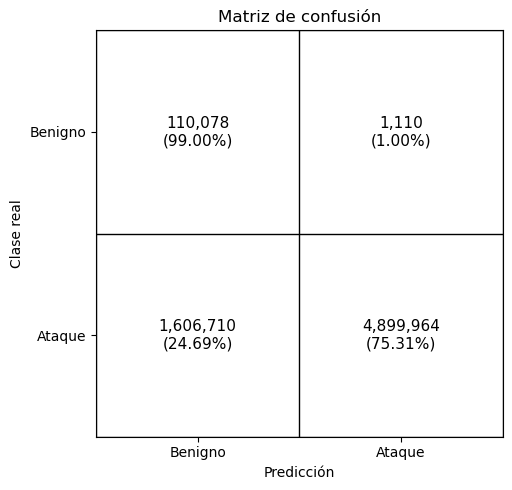

In [ ]:
# Calcular la matriz de confusión y los porcentajes normalizados por fila
cm = confusion_matrix(results_df["y_true"], results_df["y_pred"])

cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

cm_labels = np.empty_like(cm, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        cm_labels[i, j] = f"{cm[i, j]:,}\n({cm_percent[i, j]:.2f}%)"


fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(np.ones_like(cm), cmap="gray", vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm_labels[i, j],
            ha="center",
            va="center",
            fontsize=11,
        )

# Dibujar líneas de la cuadrícula
ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
ax.grid(which="minor", color="black", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Benigno", "Ataque"])
ax.set_yticklabels(["Benigno", "Ataque"])

ax.set_xlabel("Predicción")
ax.set_ylabel("Clase real")
ax.set_title("Matriz de confusión")

plt.tight_layout()
plt.show()

In [31]:
# Tabal de métricas
tn, fp, fn, tp = cm.ravel()
metrics = pd.DataFrame(
    {
        "Métrica": [
            "Recall (TPR)",
            "False Positive Rate (FPR)",
            "Balanced Accuracy",
            "Matthews Correlation Coefficient (MCC)",
            "Precision",
            "F1-score",
            "Accuracy",
            "Specificity (TNR)",
            "False Negative Rate (FNR)",
        ],
        "Valor": [
            recall_score(y_true, y_pred),
            fp / (fp + tn),
            balanced_accuracy_score(y_true, y_pred),
            matthews_corrcoef(y_true, y_pred),
            precision_score(y_true, y_pred),
            f1_score(y_true, y_pred),
            accuracy_score(y_true, y_pred),
            tn / (tn + fp),
            fn / (fn + tp),
        ],
    }
)
metrics["Valor"] = metrics["Valor"].round(4)

display(metrics)

,Métrica,Valor
0,Recall (TPR),0.7531
1,False Positive Rate (FPR),0.0100
2,Balanced Accuracy,0.8715
3,Matthews Correlation Coefficient (MCC),0.2179
4,Precision,0.9998
5,F1-score,0.8591
6,Accuracy,0.7570
7,Specificity (TNR),0.9900
8,False Negative Rate (FNR),0.2469


En primer lugar, se observa que el detector presenta una **tasa de falsos positivos reducida (FPR = 0.0100)**, lo que implica que únicamente alrededor del 1 % del tráfico benigno es clasificado erróneamente como malicioso. Este resultado es especialmente relevante en sistemas de detección de intrusiones, ya que un elevado número de falsas alarmas puede dificultar considerablemente la operación del sistema.

Sin embargo, la capacidad de detección de ataques resulta más limitada. El modelo alcanza un **Recall de 0.7531**, lo que indica que aproximadamente una de cada cuatro muestras maliciosas presentes en el conjunto de evaluación no consigue ser detectada. Esta situación también se refleja en la matriz de confusión, donde puede observarse un número considerable de falsos negativos.

La **Balanced Accuracy (0.8715)** indica que, considerando de forma equilibrada ambas clases, el detector presenta un comportamiento razonablemente bueno. No obstante, el **coeficiente de correlación de Matthews (MCC = 0.2179)** refleja que la capacidad discriminativa global del modelo es moderada cuando se consideran simultáneamente verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

Por otro lado, métricas como la **Precision (0.9998)** y la **medida F1 (0.8591)** presentan valores elevados. Sin embargo, estos resultados deben interpretarse con cautela debido al fuerte desbalanceo existente en el conjunto de evaluación, en el que las muestras de ataque son muy superiores en número a las benignas. Esta distribución favorece especialmente la obtención de valores elevados de precisión cuando el número de falsos positivos es reducido, por lo que dichas métricas no resultan suficientemente representativas para valorar por sí solas el comportamiento del detector.

En conjunto, estos resultados muestran que el detector LOF prioriza la reducción de falsas alarmas frente a la detección del mayor número posible de ataques. No obstante, este análisis se ha realizado sobre una distribución de clases poco representativa de un entorno IoT real. Por este motivo, en los siguientes apartados se estudiará con mayor detalle el comportamiento del detector desde distintas perspectivas, prestando especial atención a su rendimiento bajo escenarios con prevalencias de ataque más próximas a las que pueden encontrarse durante su despliegue en producción.

## 2. Rendimiento por dispositivo

El análisis global realizado en el apartado anterior proporciona una visión agregada del comportamiento de la estrategia basada en un detector LOF por dispositivo. Sin embargo, dicho análisis puede ocultar diferencias significativas entre los distintos dispositivos IoT presentes en el dataset, ya que cada uno de ellos presenta características propias de funcionamiento, patrones de tráfico diferentes y un modelo LOF entrenado de forma independiente.

Por este motivo, en este apartado se analiza el rendimiento obtenido por cada uno de los 9 detectores de manera individual. Este análisis permite identificar si el comportamiento observado a nivel global es homogéneo o si, por el contrario, existen dispositivos cuya detección resulta especialmente sencilla o compleja.

Al igual que en el apartado anterior, el estudio se centrará principalmente en las métricas **Recall**, **False Positive Rate (FPR)**, **Balanced Accuracy** y **Matthews Correlation Coefficient (MCC)**, ya que proporcionan una caracterización más robusta del comportamiento del detector frente al fuerte desbalanceo existente en el conjunto de evaluación.

Las restantes métricas se incluyen igualmente con fines descriptivos, permitiendo completar el análisis del rendimiento obtenido por cada uno de los modelos entrenados.

In [38]:
device_metrics = []

for device in sorted(results_df["device"].unique()):

    device_df = results_df[results_df["device"] == device]

    y_true = device_df["y_true"]
    y_pred = device_df["y_pred"]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    device_metrics.append(
        {
            "Device": device,
            "Recall": recall_score(y_true, y_pred),
            "FPR": fp / (fp + tn),
            "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
            "MCC": matthews_corrcoef(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred),
            "F1-score": f1_score(y_true, y_pred),
            "Accuracy": accuracy_score(y_true, y_pred),
            "Specificity": tn / (tn + fp),
            "FNR": fn / (fn + tp),
        }
    )

device_metrics_df = pd.DataFrame(device_metrics)

display(device_metrics_df)

,Device,Recall,FPR,Balanced Accuracy,MCC,Precision,F1-score,Accuracy,Specificity,FNR
0,1,0.795720,0.007366,0.894177,0.193021,0.999905,0.886204,0.797714,0.992634,0.204280
1,2,0.999830,0.012581,0.993624,0.967771,0.999960,0.999895,0.999790,0.987419,0.000170
2,3,0.350013,0.012404,0.668804,0.109197,0.999125,0.518415,0.365391,0.987596,0.649987
3,4,0.785247,0.009758,0.887744,0.339319,0.999529,0.879524,0.792743,0.990242,0.214753
4,5,0.727911,0.010860,0.858526,0.199419,0.999758,0.842447,0.732082,0.989140,0.272089
5,6,0.737260,0.010049,0.863606,0.257236,0.999636,0.848631,0.743828,0.989951,0.262740
6,7,0.355032,0.010067,0.672483,0.126376,0.999085,0.523895,0.374888,0.989933,0.644968
7,8,0.764070,0.009982,0.877044,0.185329,0.999851,0.866202,0.766619,0.990018,0.235930
8,9,0.757901,0.008705,0.874598,0.118749,0.999946,0.862260,0.758993,0.991295,0.242099


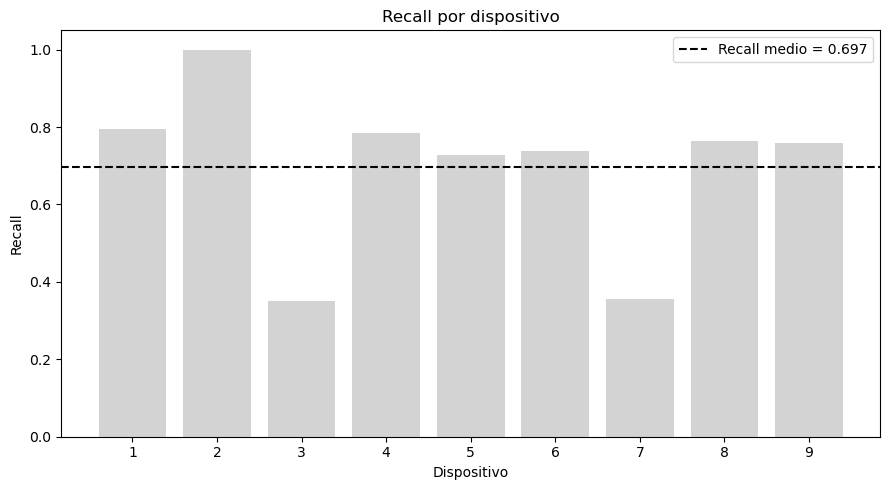

In [42]:
plt.figure(figsize=(9, 5))

plt.bar(
    device_metrics_df["Device"].astype(str),
    device_metrics_df["Recall"],
    color="lightgray"
)

plt.axhline(
    device_metrics_df["Recall"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Recall medio = {device_metrics_df['Recall'].mean():.3f}",
    color="black"
)

plt.ylim(0, 1.05)

plt.xlabel("Dispositivo")
plt.ylabel("Recall")
plt.title("Recall por dispositivo")
plt.legend()

plt.tight_layout()
plt.show()

El análisis por dispositivo muestra que el rendimiento de LOF no es homogéneo entre los distintos dispositivos IoT evaluados. Aunque la tasa de falsos positivos se mantiene en valores reducidos y relativamente estables para todos los dispositivos, la capacidad de detección de ataques presenta diferencias muy acusadas.

El caso más destacable es el **dispositivo 2**, que alcanza un Recall prácticamente perfecto, con un valor de 0.9998. Este resultado indica que el detector asociado a este dispositivo es capaz de identificar casi todas las muestras de ataque presentes en el conjunto de evaluación. Además, este dispositivo obtiene también el valor más elevado de MCC, lo que confirma que su buen rendimiento no se debe únicamente al desbalanceo del conjunto de test, sino a una separación efectiva entre muestras benignas y maliciosas.

En el extremo opuesto se encuentran los **dispositivos 3 y 7**, cuyos valores de Recall son claramente inferiores al resto, situándose aproximadamente en 0.35. Esto implica que, para estos dispositivos, el modelo LOF no detecta alrededor de dos tercios de las muestras maliciosas. Esta caída de rendimiento también se refleja en sus valores de Balanced Accuracy y MCC, que son los más bajos del conjunto.

Un aspecto especialmente relevante es que la diferencia de rendimiento entre dispositivos no parece explicarse únicamente por el número de muestras benignas disponibles para entrenamiento. De hecho, el dispositivo 2 es el que dispone de menos muestras benignas de entrenamiento y, aun así, obtiene el mejor rendimiento. Por el contrario, el dispositivo 4, que cuenta con un número considerablemente mayor de muestras benignas, no alcanza el mejor resultado. Esto sugiere que, para LOF, la cantidad de datos de entrenamiento no es necesariamente el factor dominante.

Una hipótesis más consistente con los resultados observados es que el rendimiento de LOF depende en mayor medida de la estructura del espacio de características, especialmente del grado de separación entre el tráfico benigno y el tráfico malicioso. Esta hipótesis resulta coherente con las representaciones UMAP obtenidas durante el análisis exploratorio de datos, donde algunos dispositivos muestran una separación visual más clara entre las regiones benignas y maliciosas, mientras que otros presentan mayor solapamiento entre ambas clases.

Además, los dispositivos 3 y 7 presentan una característica común relevante: son los únicos dispositivos del conjunto de evaluación que no contienen muestras de ataque de la familia Mirai, sino únicamente ataques de la familia Gafgyt. Dado que ambos dispositivos son precisamente los que obtienen peor rendimiento, se plantea la hipótesis de que los ataques Mirai podrían resultar más fácilmente separables del tráfico benigno que los ataques Gafgyt para un detector basado en densidad local como LOF. Esta hipótesis deberá contrastarse en el siguiente apartado mediante el análisis específico del rendimiento por familia de ataque.

En conjunto, los resultados indican que LOF mantiene un comportamiento estable en términos de falsas alarmas, pero su capacidad de detección depende fuertemente del dispositivo evaluado. Esta variabilidad sugiere que el comportamiento del detector está condicionado por la geometría local del tráfico benigno y por la separabilidad de los ataques respecto a dicho tráfico, más que por el volumen absoluto de muestras disponibles para el entrenamiento.

## 3. Rendimiento por familia de ataque

El apartado anterior mostró que el rendimiento de LOF presenta una variabilidad notable entre dispositivos. En particular, el dispositivo 2 obtuvo un rendimiento prácticamente perfecto, mientras que los dispositivos 3 y 7 presentaron los valores de Recall más bajos. Esta diferencia plantea una pregunta relevante: **¿las diferencias de rendimiento entre dispositivos pueden explicarse por la familia o el tipo de ataque evaluado?**

<!-- Para responder a esta cuestión, en este apartado se analiza exclusivamente el subconjunto de muestras maliciosas. Dado que todas las muestras consideradas pertenecen a ataques, el análisis se centra en la capacidad del detector para identificarlas correctamente. Por tanto, las métricas principales serán: -->

- **Recall:** proporción de muestras de ataque correctamente clasificadas como maliciosas.
- **False Negative Rate (FNR):** proporción de muestras de ataque clasificadas erróneamente como benignas.

Este análisis permite comprobar si las diferencias observadas entre dispositivos se deben a una dificultad general del detector o si, por el contrario, están asociadas a determinadas familias o tipos concretos de ataque.

In [48]:
attack_df = results_df[results_df["y_true"] == 1].copy()

### 3.1 Comparativa global por familia de ataque

En primer lugar se analiza el rendimiento agregado por familia de ataque. Este análisis permite contrastar la hipótesis planteada en el apartado anterior, según la cual los ataques de la familia Mirai podrían resultar más fácilmente separables del tráfico benigno que los ataques Gafgyt para un detector basado en densidad local como LOF.


In [49]:
family_metrics_df = (
    attack_df
    .groupby("attack_family")
    .agg(
        n_samples=("y_true", "size"),
        true_positives=("y_pred", "sum"),
    )
    .reset_index()
)

family_metrics_df["false_negatives"] = (
    family_metrics_df["n_samples"] - family_metrics_df["true_positives"]
)

family_metrics_df["Recall"] = (
    family_metrics_df["true_positives"] / family_metrics_df["n_samples"]
)

family_metrics_df["FNR"] = (
    family_metrics_df["false_negatives"] / family_metrics_df["n_samples"]
)

family_metrics_df = family_metrics_df[
    [
        "attack_family",
        "n_samples",
        "true_positives",
        "false_negatives",
        "Recall",
        "FNR",
    ]
].sort_values("Recall", ascending=False)

display(family_metrics_df)

,attack_family,n_samples,true_positives,false_negatives,Recall,FNR
1,mirai,3668402,3667917,485,0.999868,0.000132
0,gafgyt,2838272,1232047,1606225,0.434083,0.565917


Los resultados muestran un comportamiento claramente diferenciado entre ambas familias de ataques. Mientras que **Mirai** alcanza un Recall prácticamente perfecto (**99,99 %**), con únicamente **485 muestras** clasificadas erróneamente como benignas sobre más de **3,6 millones** de muestras de ataque, la familia **Gafgyt** presenta un rendimiento significativamente inferior. En este caso, el Recall desciende hasta **43,41 %**, lo que implica que más de la mitad de sus muestras (**56,59 %**) son clasificadas incorrectamente como tráfico benigno.

Estos resultados confirman la hipótesis planteada al inicio del apartado y respaldan las observaciones realizadas durante el análisis exploratorio del conjunto de datos. En términos generales, los ataques de la familia **Mirai** generan patrones de tráfico que LOF consigue distinguir con gran facilidad del tráfico benigno, mientras que los ataques **Gafgyt** presentan un comportamiento mucho más próximo a la distribución del tráfico normal, dificultando su detección mediante un algoritmo basado en densidad local.

Sin embargo, este análisis se ha realizado de forma agregada para cada familia. Dado que ambas están compuestas por varios tipos de ataque con características de tráfico diferentes, resulta necesario profundizar en el análisis para comprobar si este comportamiento es homogéneo o si existen ataques concretos que explican las diferencias observadas.

### 3.2 Comparativa global por tipo de ataque

Aunque el análisis por familia permite obtener una primera visión del comportamiento del detector, cada familia agrupa distintos tipos de ataque con patrones de tráfico potencialmente diferentes. Por este motivo, en este subapartado se desciende a un nivel de granularidad mayor y se analiza el Recall y el FNR por tipo de ataque.

El objetivo no es únicamente determinar qué familia resulta más difícil de detectar, sino identificar qué tipos concretos de ataque son los principales responsables de la caída de rendimiento observada a nivel global.

In [63]:
type_metrics_df = (
    attack_df
    .groupby(["attack_family", "attack_type"])
    .agg(
        n_samples=("y_true", "size"),
        true_positives=("y_pred", "sum"),
    )
    .reset_index()
)

type_metrics_df["false_negatives"] = (
    type_metrics_df["n_samples"] - type_metrics_df["true_positives"]
)

type_metrics_df["Recall"] = (
    type_metrics_df["true_positives"] / type_metrics_df["n_samples"]
)

type_metrics_df["FNR"] = (
    type_metrics_df["false_negatives"] / type_metrics_df["n_samples"]
)

type_metrics_df["attack_label"] = (
    type_metrics_df["attack_family"].astype(str)
    + " - "
    + type_metrics_df["attack_type"].astype(str)
)

type_metrics_df = type_metrics_df[
    [
        "attack_family",
        "attack_type",
        "attack_label",
        "n_samples",
        "true_positives",
        "false_negatives",
        "Recall",
        "FNR",
    ]
].sort_values("Recall", ascending=True)

display(type_metrics_df)

,attack_family,attack_type,attack_label,n_samples,true_positives,false_negatives,Recall,FNR
3,gafgyt,tcp,gafgyt - tcp,859850,95417,764433,0.110969,0.889031
4,gafgyt,udp,gafgyt - udp,946366,105128,841238,0.111086,0.888914
2,gafgyt,scan,gafgyt - scan,255111,254728,383,0.998499,0.001501
6,mirai,scan,mirai - scan,537979,537687,292,0.999457,0.000543
1,gafgyt,junk,gafgyt - junk,261789,261702,87,0.999668,0.000332
0,gafgyt,combo,gafgyt - combo,515156,515072,84,0.999837,0.000163
7,mirai,syn,mirai - syn,733299,733240,59,0.999920,0.000080
5,mirai,ack,mirai - ack,643821,643773,48,0.999925,0.000075
8,mirai,udp,mirai - udp,1229999,1229936,63,0.999949,0.000051
9,mirai,udpplain,mirai - udpplain,523304,523281,23,0.999956,0.000044


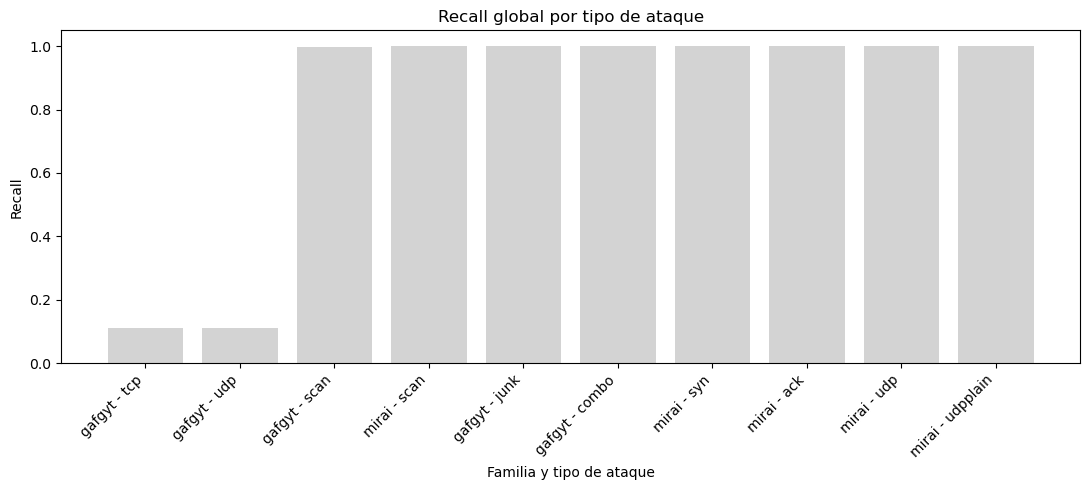

In [62]:
plt.figure(figsize=(11, 5))

type_metrics_df = type_metrics_df.sort_values("Recall", ascending=True)
plt.bar(
    type_metrics_df["attack_label"],
    type_metrics_df["Recall"],
    color="lightgray"
)

plt.ylim(0, 1.05)

plt.xlabel("Familia y tipo de ataque")
plt.ylabel("Recall")
plt.title("Recall global por tipo de ataque")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

El análisis por tipo de ataque revela que el bajo rendimiento observado anteriormente para la familia **Gafgyt** no afecta por igual a todos sus ataques. De hecho, se distinguen claramente 2 comportamientos muy diferentes.

Por un lado, los ataques **Gafgyt Scan**, **Gafgyt Junk** y **Gafgyt Combo** presentan un Recall prácticamente perfecto, superior al **99,8 %**, obteniendo un rendimiento comparable al de todos los ataques de la familia **Mirai**. Esto indica que estos ataques generan patrones de tráfico suficientemente distintos del tráfico benigno como para ser detectados con gran fiabilidad mediante LOF.

Por otro lado, los ataques **Gafgyt TCP** y **Gafgyt UDP** constituyen una excepción muy marcada. Ambos alcanzan un Recall cercano al **11 %**, lo que implica que aproximadamente **nueve de cada diez muestras** son clasificadas erróneamente como benignas. Este comportamiento explica prácticamente por completo la caída del Recall global observada para la familia Gafgyt en el apartado anterior, ya que además corresponden a los dos tipos de ataque con mayor número de muestras dentro de dicha familia.

En contraste, todos los ataques pertenecientes a la familia **Mirai** mantienen un rendimiento prácticamente perfecto, con valores de Recall superiores al **99,94 %** y tasas de falsos negativos prácticamente nulas. Esto confirma que la excelente capacidad de detección observada para esta familia es consistente independientemente del tipo de ataque considerado.

En conjunto, estos resultados muestran que la dificultad de LOF para detectar ataques no depende únicamente de la familia a la que pertenecen, sino principalmente del patrón de tráfico generado por determinados tipos de ataque. En particular, los ataques **Gafgyt TCP** y **Gafgyt UDP** representan el principal punto débil del detector, mientras que el resto de ataques son identificados con una fiabilidad prácticamente perfecta.

### 3.3 Relación con el rendimiento por dispositivo

Finalmente, se analiza con mayor detalle el comportamiento de los dispositivos que representan los casos más extremos observados en el apartado anterior: 
- El dispositivo 2, que obtuvo el mejor rendimiento
- Los dispositivos 3 y 7, que presentaron los valores de Recall más bajos.

Este análisis permite estudiar si el comportamiento extremo de estos dispositivos está relacionado con los tipos de ataque presentes en su conjunto de evaluación. Para ello, se comparará el Recall por familia y por tipo de ataque en estos tres dispositivos, con el objetivo de comprobar si las diferencias de rendimiento pueden explicarse por la composición y dificultad de los ataques evaluados.

In [54]:
extreme_devices = [2, 3, 7]

extreme_attack_df = attack_df[
    attack_df["device"].isin(extreme_devices)
].copy()

In [65]:
extreme_type_metrics_df = (
    extreme_attack_df
    .groupby(["device", "attack_family", "attack_type"])
    .agg(
        n_samples=("y_true", "size"),
        true_positives=("y_pred", "sum"),
    )
    .reset_index()
)

extreme_type_metrics_df["false_negatives"] = (
    extreme_type_metrics_df["n_samples"] - extreme_type_metrics_df["true_positives"]
)

extreme_type_metrics_df["Recall"] = (
    extreme_type_metrics_df["true_positives"] / extreme_type_metrics_df["n_samples"]
)

extreme_type_metrics_df["FNR"] = (
    extreme_type_metrics_df["false_negatives"] / extreme_type_metrics_df["n_samples"]
)

extreme_type_metrics_df["attack_label"] = (
    extreme_type_metrics_df["attack_family"].astype(str)
    + " - "
    + extreme_type_metrics_df["attack_type"].astype(str)
)

display(
    extreme_type_metrics_df[
        [
            "device",
            "attack_family",
            "attack_type",
            "n_samples",
            "true_positives",
            "false_negatives",
            "Recall",
            "FNR",
        ]
    ].sort_values(["device", "Recall"])
)

,device,attack_family,attack_type,n_samples,true_positives,false_negatives,Recall,FNR
3,2,gafgyt,tcp,95021,94955,66,0.999305,0.000695
4,2,gafgyt,udp,104791,104730,61,0.999418,0.000582
1,2,gafgyt,junk,30312,30308,4,0.999868,0.000132
7,2,mirai,syn,116807,116802,5,0.999957,0.000043
0,2,gafgyt,combo,53012,53010,2,0.999962,0.000038
9,2,mirai,udpplain,87368,87367,1,0.999989,0.000011
5,2,mirai,ack,113285,113284,1,0.999991,0.000009
2,2,gafgyt,scan,27494,27494,0,1.000000,0.000000
6,2,mirai,scan,43192,43192,0,1.000000,0.000000
8,2,mirai,udp,151481,151481,0,1.000000,0.000000


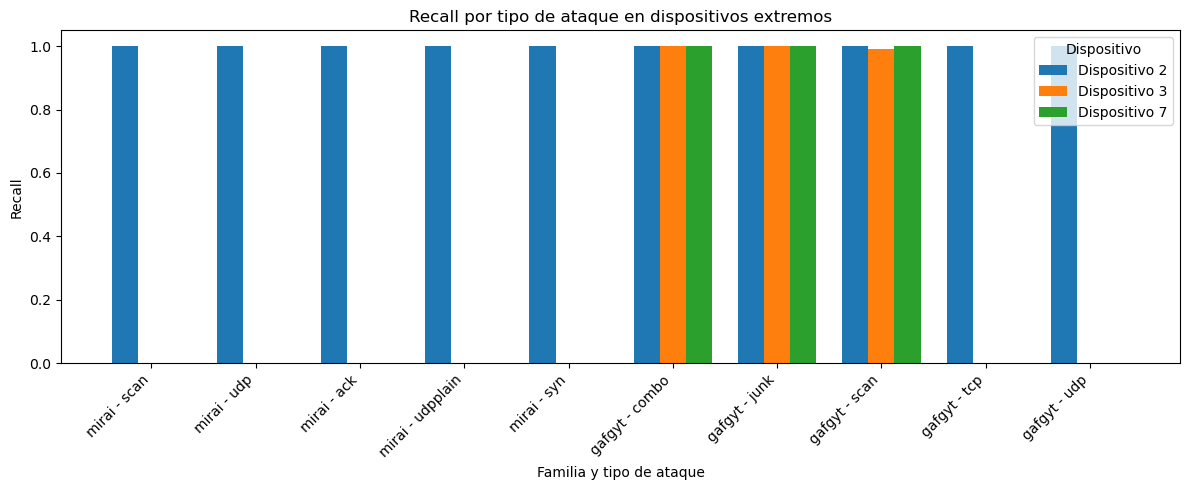

In [66]:
extreme_type_recall_df = (
    extreme_type_metrics_df
    .pivot(
        index="attack_label",
        columns="device",
        values="Recall",
    )
)

# Ordenar los ataques por el Recall medio de los dispositivos donde aparecen
extreme_type_recall_df = extreme_type_recall_df.loc[
    extreme_type_recall_df.mean(axis=1).sort_values(ascending=False).index
]

x = np.arange(len(extreme_type_recall_df.index))
bar_width = 0.25

plt.figure(figsize=(12, 5))

for offset, device in enumerate(extreme_devices):
    values = extreme_type_recall_df[device] if device in extreme_type_recall_df.columns else np.nan

    plt.bar(
        x + (offset - 1) * bar_width,
        values,
        width=bar_width,
        label=f"Dispositivo {device}",
    )

plt.ylim(0, 1.05)

plt.xlabel("Familia y tipo de ataque")
plt.ylabel("Recall")
plt.title("Recall por tipo de ataque en dispositivos extremos")

plt.xticks(
    x,
    extreme_type_recall_df.index,
    rotation=45,
    ha="right",
)

plt.legend(title="Dispositivo")

plt.tight_layout()
plt.show()

Los resultados muestran que los dispositivos extremos presentan comportamientos claramente diferenciados ante los distintos tipos de ataque. El **dispositivo 2** mantiene un Recall prácticamente perfecto para todos los ataques evaluados, incluidos **Gafgyt TCP** y **Gafgyt UDP**, que habían sido identificados previamente como los tipos más problemáticos a nivel global.

En cambio, los **dispositivos 3 y 7** presentan un rendimiento muy bajo precisamente en esos 2 ataques. Esto explica gran parte de su bajo rendimiento global.

Este análisis permite matizar la conclusión obtenida en los apartados anteriores. Los ataques **Gafgyt TCP** y **Gafgyt UDP** son los principales responsables de la caída de rendimiento de LOF, pero su dificultad no es igual para todos los dispositivos. El caso del **dispositivo 2** demuestra que estos ataques pueden ser detectados correctamente cuando su patrón se separa claramente del tráfico benigno del dispositivo.

Por tanto, el rendimiento de LOF no depende únicamente de la familia o del tipo de ataque, sino también del dispositivo monitorizado y de la distribución concreta de su tráfico benigno. En este caso, los dispositivos **3** y **7** se ven especialmente penalizados porque solo contienen ataques de la familia **Gafgyt** y, dentro de ella, los tipos **TCP** y **UDP** son los que presentan una menor separabilidad para LOF.

## 4. Análisis de margen de mejora mediante ajuste supervisado del *threshold*

En los apartados anteriores se ha observado que el bajo rendimiento de LOF se concentra principalmente en los ataques **Gafgyt TCP** y **Gafgyt UDP**. Sin embargo, estos resultados no permiten distinguir si el problema se debe a una separación insuficiente entre las distribuciones de score o a una selección de *threshold* demasiado conservadora.

Por este motivo, en este apartado se analiza el margen de mejora que podría obtenerse sin reentrenar los modelos, únicamente ajustando el *threshold* de decisión. Para ello, se compara el *threshold* seleccionado mediante el procedimiento no supervisado con un *threshold* óptimo calculado de forma *post-hoc* sobre el conjunto de test.

Este *threshold* óptimo se obtiene maximizando el **Matthews Correlation Coefficient (MCC)**, ya que esta métrica considera simultáneamente verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos, siendo adecuada en escenarios con fuerte desbalanceo entre clases.

Es importante destacar que este *threshold* óptimo no forma parte del procedimiento experimental no supervisado, ya que utiliza las etiquetas del conjunto de test. Su objetivo es actuar como una referencia tipo *oracle* para estimar cuánto podría mejorar el sistema mediante una recalibración supervisada del *threshold*, sin modificar el modelo LOF entrenado.

In [5]:
CURRENT_THRESHOLDS = {
    1: 2.9840,
    2: 6.2190,
    3: 15.4133,
    4: 2.0849,
    5: 2.6026,
    6: 2.4490,
    7: 3.7893,
    8: 3.2468,
    9: 5.8626,
}

def find_optimal_threshold_by_mcc(
    y_true,
    scores,
    n_candidates=2000,
    min_quantile=0.0,
    max_quantile=1.0,
):
    """
    Calcula un threshold aproximado maximizando MCC sobre una rejilla de cuantiles.
    Se asume que mayor score implica mayor anomalía.
    """

    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    quantiles = np.linspace(min_quantile, max_quantile, n_candidates)
    candidate_thresholds = np.quantile(scores, quantiles)
    candidate_thresholds = np.unique(candidate_thresholds)

    best_threshold = None
    best_mcc = -np.inf

    for th in tqdm(candidate_thresholds):
        y_pred = (scores > th).astype(int)
        mcc = matthews_corrcoef(y_true, y_pred)

        if mcc > best_mcc:
            best_mcc = mcc
            best_threshold = th

    return {
        "threshold": best_threshold,
        "mcc": best_mcc,
    }


def compute_binary_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "FPR": fp / (fp + tn),
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    }

In [7]:
threshold_rows = []

for device in sorted(results_df["device"].unique()):
    device_df = results_df[results_df["device"] == device].copy()

    y_true = device_df["y_true"].astype(int).to_numpy()
    scores = device_df["score"].to_numpy()

    current_th = CURRENT_THRESHOLDS[device]
    optimal_info = find_optimal_threshold_by_mcc(y_true, scores, n_candidates=1000, min_quantile=0.0, max_quantile=0.3)
    optimal_th = optimal_info["threshold"]

    y_pred_current = (scores > current_th).astype(int)
    y_pred_optimal = (scores > optimal_th).astype(int)

    current_metrics = compute_binary_metrics(y_true, y_pred_current)
    optimal_metrics = compute_binary_metrics(y_true, y_pred_optimal)

    threshold_rows.append({
        "device": device,
        "current_threshold": current_th,
        "optimal_threshold": optimal_th,

        "current_recall": current_metrics["Recall"],
        "optimal_recall": optimal_metrics["Recall"],

        "current_fpr": current_metrics["FPR"],
        "optimal_fpr": optimal_metrics["FPR"],

        "current_precision": current_metrics["Precision"],
        "optimal_precision": optimal_metrics["Precision"],

        "current_mcc": current_metrics["MCC"],
        "optimal_mcc": optimal_metrics["MCC"],
    })

threshold_analysis_df = pd.DataFrame(threshold_rows)

display(threshold_analysis_df.round(4))

100%|██████████| 200/200 [00:25<00:00,  7.85it/s]


,device,current_threshold,optimal_threshold,current_recall,optimal_recall,current_fpr,optimal_fpr,current_precision,optimal_precision,current_mcc,optimal_mcc
0,1,2.9840,0.9917,0.7957,1.0000,0.0074,0.8519,0.9999,0.9914,0.1930,0.3829
1,2,6.2190,2.2667,0.9998,1.0000,0.0126,0.0549,1.0000,0.9998,0.9678,0.9721
2,3,15.4133,3.4907,0.3500,0.9999,0.0124,0.0957,0.9991,0.9976,0.1092,0.9474
3,4,2.0849,4.1224,0.7852,0.7848,0.0098,0.0007,0.9995,1.0000,0.3393,0.3428
4,5,2.6026,1.0432,0.7279,0.9999,0.0109,0.5720,0.9998,0.9908,0.1994,0.6476
5,6,2.4490,1.0946,0.7373,0.9999,0.0100,0.3665,0.9996,0.9903,0.2572,0.7907
6,7,3.7893,1.0391,0.3550,0.9999,0.0101,0.5322,0.9991,0.9831,0.1264,0.6760
7,8,3.2468,0.9852,0.7641,1.0000,0.0100,0.8935,0.9999,0.9899,0.1853,0.3246
8,9,5.8626,1.3552,0.7579,1.0000,0.0087,0.2317,0.9999,0.9989,0.1187,0.8747


In [8]:
def assign_score_group(row):
    if row["y_true"] == 0:
        return "Benigno"

    if row["attack_family"] == "gafgyt" and row["attack_type"] in ["tcp", "udp"]:
        return "Gafgyt TCP/UDP"

    return "Resto de ataques"


plot_df = results_df.copy()
plot_df["score_group"] = plot_df.apply(assign_score_group, axis=1)


COLOR_GROUPS = [
    ("Benigno", "tab:blue", 0.45),
    ("Gafgyt TCP/UDP", "tab:red", 0.45),
    ("Resto de ataques", "lightcoral", 0.35),
]

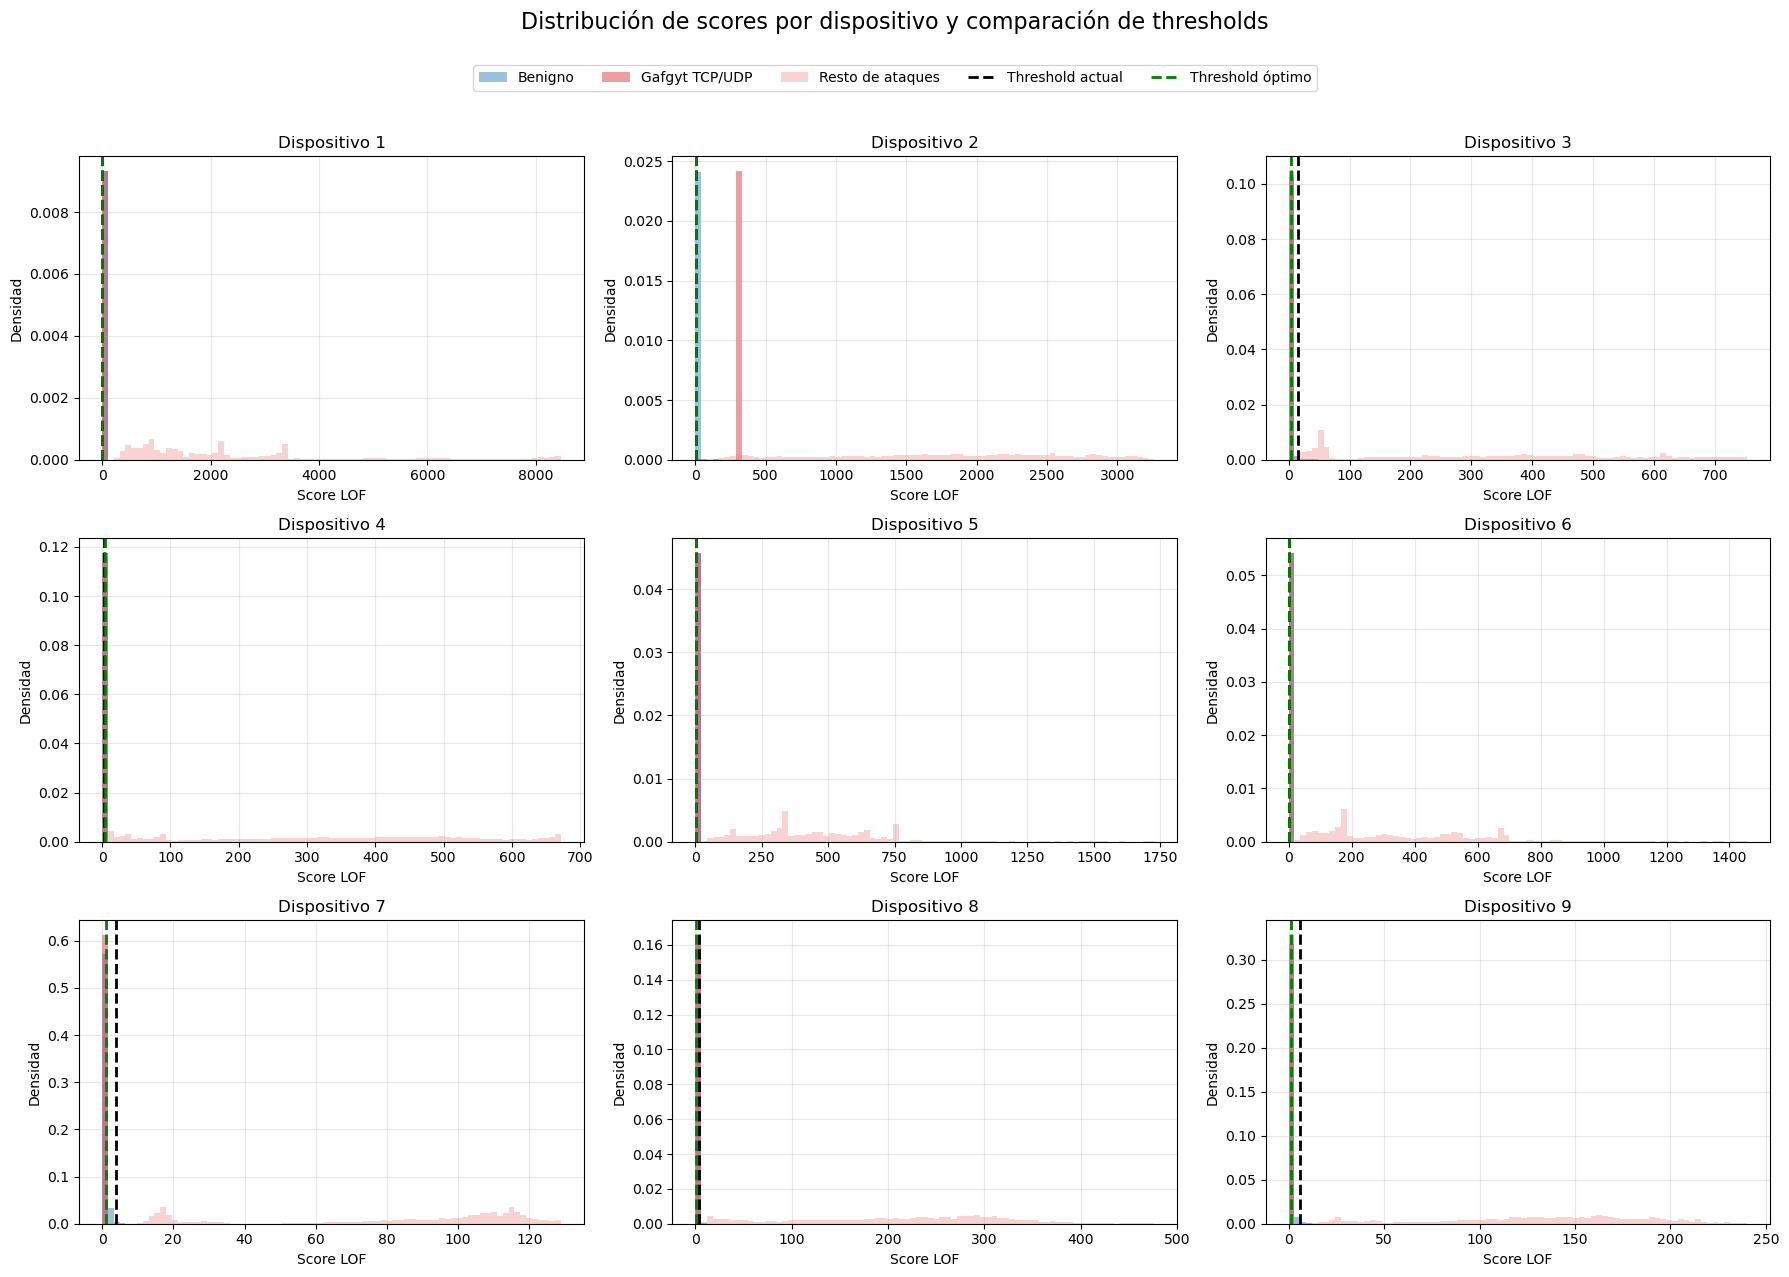

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, device in zip(axes, sorted(plot_df["device"].unique())):
    device_df = plot_df[plot_df["device"] == device]

    current_th = CURRENT_THRESHOLDS[device]
    optimal_th = threshold_analysis_df.loc[
        threshold_analysis_df["device"] == device,
        "optimal_threshold"
    ].iloc[0]

    max_score_for_plot = np.quantile(device_df["score"], 0.995)
    max_score_for_plot = max(max_score_for_plot, current_th, optimal_th)

    bins = np.linspace(0, max_score_for_plot, 80)

    for group_name, color, alpha in COLOR_GROUPS:
        values = device_df.loc[
            device_df["score_group"] == group_name,
            "score"
        ]

        if len(values) == 0:
            continue

        ax.hist(
            values,
            bins=bins,
            density=True,
            alpha=alpha,
            color=color,
            label=group_name,
        )

    ax.axvline(
        current_th,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Threshold actual",
    )

    ax.axvline(
        optimal_th,
        color="green",
        linestyle="--",
        linewidth=2,
        label="Threshold óptimo",
    )

    ax.set_title(f"Dispositivo {device}")
    ax.set_xlabel("Score LOF")
    ax.set_ylabel("Densidad")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Distribución de scores por dispositivo y comparación de thresholds",
    fontsize=16,
    y=1.06,
)

fig.tight_layout()
plt.show()

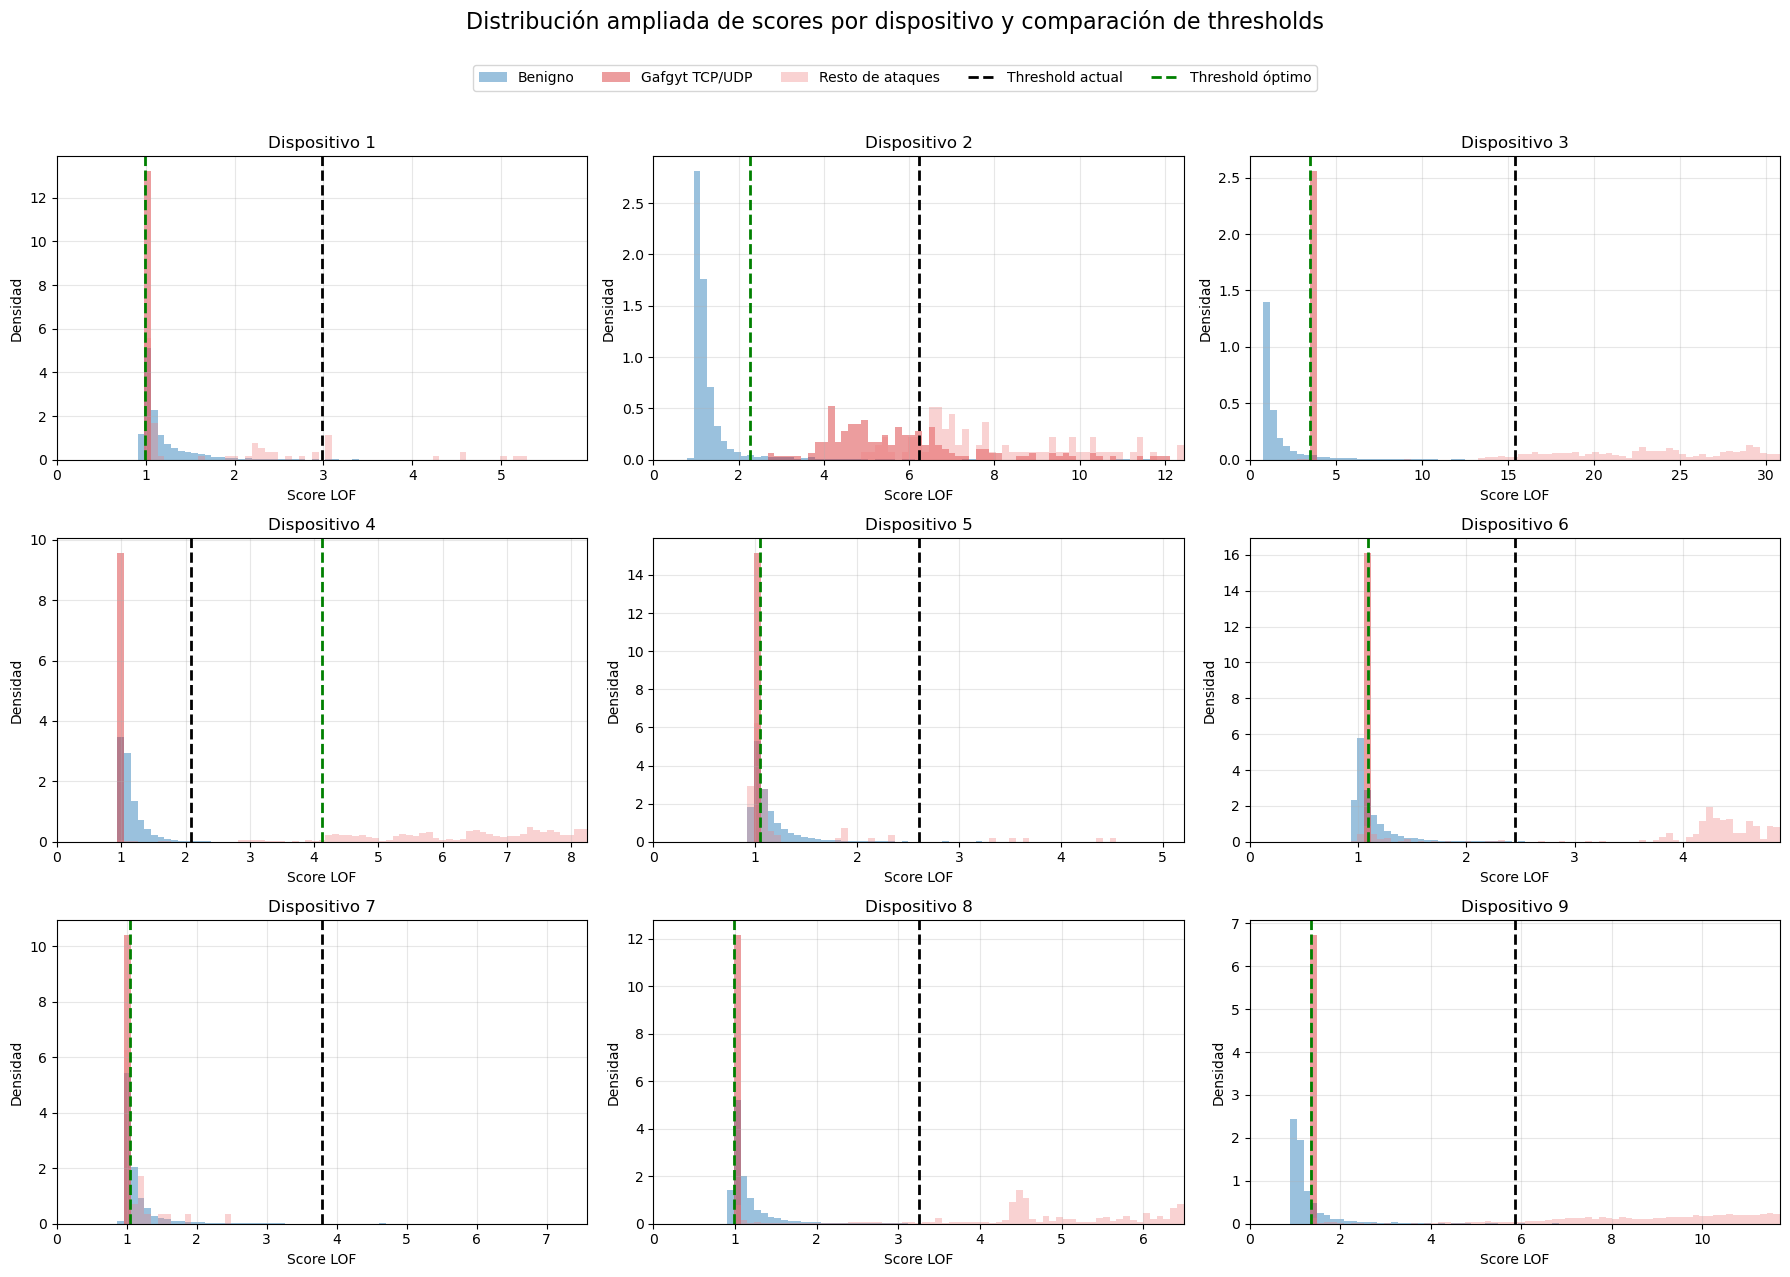

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, device in zip(axes, sorted(plot_df["device"].unique())):
    device_df = plot_df[plot_df["device"] == device]

    current_th = CURRENT_THRESHOLDS[device]
    optimal_th = threshold_analysis_df.loc[
        threshold_analysis_df["device"] == device,
        "optimal_threshold"
    ].iloc[0]

    max_score_for_plot = max(current_th * 2, optimal_th * 2)

    bins = np.linspace(0, max_score_for_plot, 80)

    for group_name, color, alpha in COLOR_GROUPS:
        values = device_df.loc[
            device_df["score_group"] == group_name,
            "score"
        ]

        if len(values) == 0:
            continue

        ax.hist(
            values,
            bins=bins,
            density=True,
            alpha=alpha,
            color=color,
            label=group_name,
        )

        ax.set_xlim(0,max_score_for_plot)

    ax.axvline(
        current_th,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Threshold actual",
    )

    ax.axvline(
        optimal_th,
        color="green",
        linestyle="--",
        linewidth=2,
        label="Threshold óptimo",
    )

    ax.set_title(f"Dispositivo {device}")
    ax.set_xlabel("Score LOF")
    ax.set_ylabel("Densidad")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Distribución ampliada de scores por dispositivo y comparación de thresholds",
    fontsize=16,
    y=1.06,
)

fig.tight_layout()
plt.show()

Los resultados muestran que el procedimiento de selección del *threshold* no constituye el principal factor limitante del rendimiento de LOF. En la mayoría de los dispositivos, el *threshold* óptimo obtenido de forma supervisada se sitúa considerablemente por debajo del *threshold* seleccionado mediante el procedimiento no supervisado, lo que permite incrementar notablemente el Recall. Sin embargo, esta mejora viene acompañada de un aumento muy acusado del **False Positive Rate (FPR)**, que en algunos dispositivos supera ampliamente el **50 %** de las muestras benignas.

Este comportamiento puede explicarse a partir de las distribuciones de score observadas. Mientras que la mayoría de los ataques presentan valores de score claramente superiores a los del tráfico benigno, los ataques **Gafgyt TCP** y **Gafgyt UDP** se sitúan precisamente en la región donde finaliza la distribución del tráfico benigno. Como consecuencia, existe un solapamiento importante entre ambas distribuciones, de modo que reducir el *threshold* permite recuperar gran parte de estos ataques únicamente a costa de clasificar un elevado número de muestras benignas como maliciosas.

En contraste, el resto de ataques aparecen claramente separados del tráfico benigno para prácticamente todos los dispositivos, lo que explica que sean detectados con una fiabilidad cercana al **100 %** independientemente del *threshold* utilizado.

El **dispositivo 2** constituye nuevamente una excepción. En este caso, incluso los ataques **Gafgyt TCP** y **Gafgyt UDP** presentan una separación mucho más clara respecto al tráfico benigno, lo que permite desplazar el *threshold* hacia valores inferiores sin provocar un incremento tan acusado del FPR. Este comportamiento es coherente con el excelente rendimiento observado para este dispositivo a lo largo de todo el análisis.

En conjunto, este estudio pone de manifiesto que el margen de mejora de LOF mediante una simple recalibración del *threshold* es limitado. Aunque es posible aumentar significativamente el Recall, dicha mejora implica un incremento muy importante de la tasa de falsas alarmas en la mayoría de los dispositivos. Por tanto, los resultados sugieren que la principal limitación del detector no reside en la estrategia de selección del *threshold*, sino en la capacidad discriminativa de los scores generados por LOF para separar el tráfico benigno de determinados tipos de ataque.

## 5. Sensibilidad frente a prevalencia de ataque

Hasta este punto, la evaluación del modelo se ha realizado utilizando el conjunto de prueba original del dataset. Sin embargo, esta distribución no refleja el comportamiento esperado en un entorno IoT real, donde la inmensa mayoría del tráfico corresponde a actividad benigna y únicamente una pequeña fracción está asociada a ataques.

En escenarios de producción, la prevalencia de ataques tiene una influencia directa sobre determinadas métricas de evaluación. En particular, métricas como la **Precisión (Precision)** o el **F1-Score** dependen de la proporción existente entre tráfico benigno y tráfico malicioso, por lo que un modelo que obtiene buenos resultados sobre un conjunto de datos balanceado puede ofrecer un rendimiento significativamente diferente cuando se despliega en un entorno donde los ataques son poco frecuentes.

Con el objetivo de aproximar la evaluación a un escenario más realista, en este apartado se simulan diferentes prevalencias de ataque manteniendo todas las muestras benignas del conjunto de prueba y reduciendo aleatoriamente el número de muestras de ataque hasta alcanzar distintas proporciones representativas de un entorno de producción. Para reducir el efecto del muestreo aleatorio, cada experimento se repite varias veces y las métricas finales se calculan como la media de todas las repeticiones.

Este análisis permite estimar cuál sería el comportamiento esperado del detector una vez desplegado, proporcionando una visión más representativa de su utilidad práctica que la obtenida únicamente a partir de la distribución original del dataset.

In [74]:
ATTACK_PREVALENCES = [
    0.10,
    0.05,
    0.01,
    0.005,
    0.001,
]

N_REPEATS = 30

RANDOM_STATE = 42

benign_df = results_df[results_df["y_true"] == 0].copy()
attack_df = results_df[results_df["y_true"] == 1].copy()

In [76]:
def compute_metrics(df):

    y_true = df["y_true"]
    y_pred = df["y_pred"]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "FPR": fp / (fp + tn),
    }

rng = np.random.default_rng(RANDOM_STATE)

all_results = []

n_benign = len(benign_df)

for prevalence in ATTACK_PREVALENCES:

    n_attack = int(
        prevalence / (1 - prevalence) * n_benign
    )

    for repeat in range(N_REPEATS):

        sampled_attack = attack_df.sample(
            n=n_attack,
            replace=False,
            random_state=rng.integers(0, 1_000_000),
        )

        evaluation_df = pd.concat(
            [benign_df, sampled_attack],
            ignore_index=True,
        )

        metrics = compute_metrics(evaluation_df)

        metrics["Attack prevalence"] = prevalence
        metrics["Repeat"] = repeat

        all_results.append(metrics)

prevalence_results = pd.DataFrame(all_results)

In [78]:
summary = (
    prevalence_results
    .groupby("Attack prevalence")
    .agg({
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "FPR": ["mean", "std"],
        "MCC": ["mean", "std"],
    })
)

summary = summary.round(4)

display(summary)

Precision          Recall           FPR          MCC        
                       mean     std    mean     std  mean  std    mean     std
Attack prevalence                                                             
0.001                0.0691  0.0032  0.7429  0.0368  0.01  0.0  0.2247  0.0109
0.005                0.2746  0.0040  0.7533  0.0151  0.01  0.0  0.4508  0.0079
0.010                0.4320  0.0044  0.7518  0.0134  0.01  0.0  0.5644  0.0081
0.050                0.7988  0.0010  0.7532  0.0045  0.01  0.0  0.7643  0.0029
0.100                0.8933  0.0006  0.7524  0.0047  0.01  0.0  0.8020  0.0030

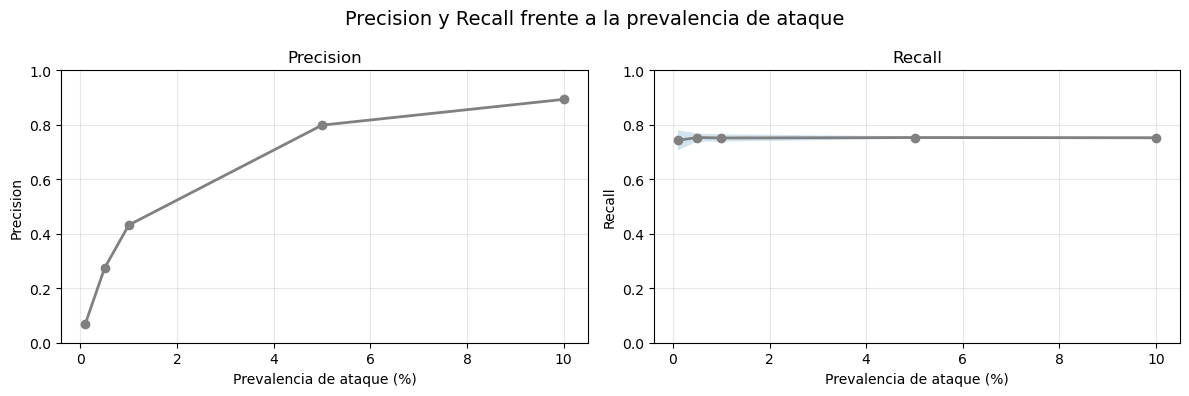

In [84]:
plot_summary = (
    prevalence_results
    .groupby("Attack prevalence")
    .agg({
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "FPR": ["mean", "std"],
        "MCC": ["mean", "std"],
    })
    .sort_index()
)

prevalence_values = plot_summary.index.to_numpy() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

metrics_to_plot = ["Precision", "Recall"]

for ax, metric in zip(axes, metrics_to_plot):
    mean_values = plot_summary[(metric, "mean")].to_numpy()
    std_values = plot_summary[(metric, "std")].to_numpy()

    ax.plot(prevalence_values, mean_values, marker="o", linewidth=2, color="gray")
    ax.fill_between(
        prevalence_values,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.2,
    )

    ax.set_title(metric)
    ax.set_xlabel("Prevalencia de ataque (%)")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

fig.suptitle("Precision y Recall frente a la prevalencia de ataque", fontsize=14)
fig.tight_layout()
plt.show()

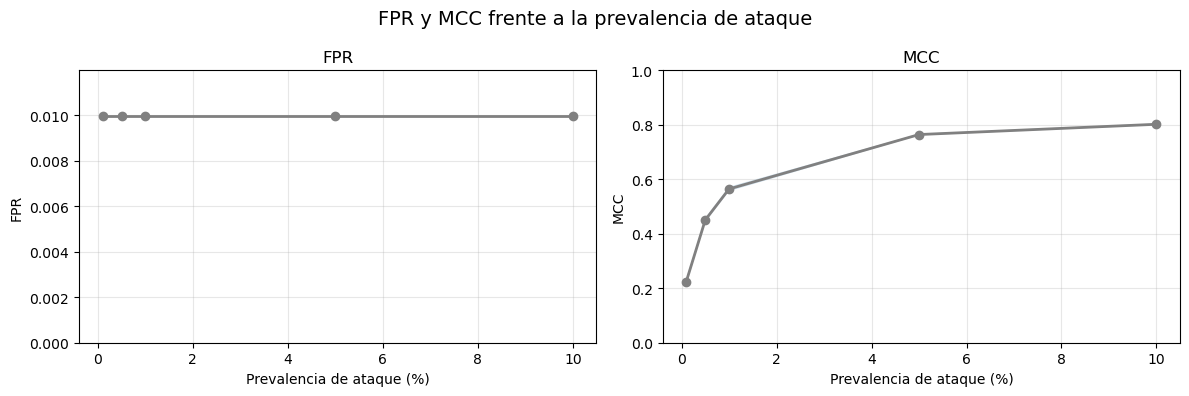

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

metrics_to_plot = ["FPR", "MCC"]

for ax, metric in zip(axes, metrics_to_plot):
    mean_values = plot_summary[(metric, "mean")].to_numpy()
    std_values = plot_summary[(metric, "std")].to_numpy()

    ax.plot(prevalence_values, mean_values, marker="o", linewidth=2, color="gray")
    ax.fill_between(
        prevalence_values,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.2,
    )

    ax.set_title(metric)
    ax.set_xlabel("Prevalencia de ataque (%)")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

    if metric == "FPR":
        ax.set_ylim(0, max((mean_values + std_values).max() * 1.2, 0.01))
    else:
        ax.set_ylim(0, 1)

fig.suptitle("FPR y MCC frente a la prevalencia de ataque", fontsize=14)
fig.tight_layout()
plt.show()

Los resultados muestran que la **prevalencia de ataques tiene un impacto muy significativo sobre la Precision y el MCC**, mientras que el **Recall** y el **False Positive Rate (FPR)** permanecen prácticamente constantes.

En primer lugar, el **Recall** se mantiene estable en torno al **75 %** para todas las prevalencias evaluadas. Este comportamiento era esperable, ya que la capacidad del detector para identificar correctamente una muestra maliciosa no depende de la proporción de ataques presente en el conjunto de evaluación, sino de la capacidad intrínseca del modelo para distinguir el tráfico malicioso del benigno.

Del mismo modo, el **FPR** permanece constante alrededor del **1 %**, lo que confirma que el detector mantiene una tasa de falsas alarmas muy similar independientemente de la prevalencia de ataques. Al conservarse todas las muestras benignas durante la simulación, este resultado refleja que el comportamiento del modelo sobre el tráfico legítimo es estable.

Por el contrario, la **Precision** experimenta una disminución muy acusada a medida que disminuye la prevalencia de ataques. Mientras que con una prevalencia del **10 %** aproximadamente **9 de cada 10 alertas** corresponden realmente a un ataque, este porcentaje desciende hasta apenas un **7 %** cuando la prevalencia es del **0,1 %**. En otras palabras, en un escenario donde los ataques son muy poco frecuentes, la mayoría de las alertas generadas por el sistema serían falsos positivos, a pesar de que el detector mantiene la misma capacidad para identificar ataques y la misma tasa de falsas alarmas.

Esta degradación también se refleja en el **Matthews Correlation Coefficient (MCC)**, que disminuye progresivamente desde **0,80** hasta **0,22** conforme disminuye la prevalencia. Al tratarse de una métrica que considera simultáneamente verdaderos y falsos positivos y negativos, el MCC pone de manifiesto la pérdida de rendimiento global del detector cuando se evalúa en condiciones más próximas a un entorno de producción.

En conjunto, estos resultados evidencian la importancia de evaluar los sistemas de detección de intrusiones bajo distribuciones de clases representativas de su escenario de despliegue. Aunque LOF mantiene un comportamiento estable en términos de **Recall** y **FPR**, la baja prevalencia de ataques característica de las redes IoT provoca una reducción considerable de la **Precision**, limitando la utilidad práctica del sistema al incrementar significativamente el número de falsas alertas que deben ser analizadas por un administrador.

## 6. Escalabilidad de LOF

## 7. Conclusiones específicas de LOF